# **Setup Enviroment**

In [2]:
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from lib.layers import Dense
from lib.activations import ReLU, Sigmoid, Tanh, Softmax
from lib.losses import MSE
from lib.optimizer import SGD
from lib.network import Sequential

print("Library imported successfully!")


Library imported successfully!


# **Section 1:  Gradient Checking**

In [3]:
# Cell 2: Gradient Checking Function
def gradient_checking(layer, X, epsilon=1e-7):
    
    print("=" * 60)
    print("GRADIENT CHECKING")
    print("=" * 60)
    
    # Forward pass
    output = layer.forward(X)
    
    # Create arbitrary gradient (simulating gradient from next layer)
    output_gradient = np.ones_like(output)
    
    # Backward pass to get analytical gradients
    layer.backward(output_gradient)
    
    if hasattr(layer, 'weights'):
        analytical_grad = layer.weights_gradient
        numerical_grad = np.zeros_like(layer.weights)
        
        # Compute numerical gradient for each weight
        print(f"Computing numerical gradients for {layer.weights.size} parameters...")
        
        it = np.nditer(layer.weights, flags=['multi_index'], op_flags=['readwrite'])
        while not it.finished:
            idx = it.multi_index
            
            old_value = layer.weights[idx]
            
            # f(x + epsilon)
            layer.weights[idx] = old_value + epsilon
            output_plus = np.sum(layer.forward(X))
            
            # f(x - epsilon)
            layer.weights[idx] = old_value - epsilon
            output_minus = np.sum(layer.forward(X))
            
            # Numerical gradient: [f(x+ε) - f(x-ε)] / (2ε)
            numerical_grad[idx] = (output_plus - output_minus) / (2 * epsilon)
            
            # Restore original value
            layer.weights[idx] = old_value
            
            it.iternext()
        
        # Compare gradients
        difference = np.linalg.norm(analytical_grad - numerical_grad) / (
            np.linalg.norm(analytical_grad) + np.linalg.norm(numerical_grad)
        )
        
        print(f"\nAnalytical Gradient (sample):\n{analytical_grad[:2, :2]}")
        print(f"\nNumerical Gradient (sample):\n{numerical_grad[:2, :2]}")
        print(f"\nRelative difference: {difference:.10f}")
        
        if difference < 1e-5:
            print("Gradient check PASSED! Backpropagation is correct.")
        else:
            print(" Gradient check FAILED! Check your backward() implementation.")
        
        return difference
    else:
        print("Layer has no parameters to check.")

In [4]:
# Cell 3: Test Gradient Checking
print("Testing Dense Layer Gradient Checking:\n")
test_layer = Dense(3, 2)
test_input = np.random.randn(5, 3)
gradient_checking(test_layer, test_input)

Testing Dense Layer Gradient Checking:

GRADIENT CHECKING
Computing numerical gradients for 6 parameters...

Analytical Gradient (sample):
[[-1.34051952 -1.34051952]
 [-0.30318197 -0.30318197]]

Numerical Gradient (sample):
[[-1.34051952 -1.34051952]
 [-0.30318197 -0.30318197]]

Relative difference: 0.0000000006
Gradient check PASSED! Backpropagation is correct.


np.float64(5.696440384075485e-10)

# **Section 2:  The XOR problem**

In [5]:
# Cell 4: XOR Dataset
print("\n" + "=" * 60)
print("XOR PROBLEM")
print("=" * 60)

# XOR truth table
X_xor = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]], dtype=float)

y_xor = np.array([[0],
                  [1],
                  [1],
                  [0]], dtype=float)

print("\nXOR Dataset:")
print("-" * 30)
for i in range(len(X_xor)):
    print(f"Input: {X_xor[i]} → Target: {y_xor[i][0]}")


XOR PROBLEM

XOR Dataset:
------------------------------
Input: [0. 0.] → Target: 0.0
Input: [0. 1.] → Target: 1.0
Input: [1. 0.] → Target: 1.0
Input: [1. 1.] → Target: 0.0


In [6]:
# Cell 5: Build and Train XOR Network
print("\n" + "=" * 60)
print("Building Network: 2 → 4 → 1")
print("=" * 60)

# Create model
model = Sequential()
model.add(Dense(2, 4))      # 2 inputs → 4 hidden neurons
model.add(Tanh())            # Tanh activation
model.add(Dense(4, 1))       # 4 hidden → 1 output
model.add(Sigmoid())         # Sigmoid output (0 to 1)

# Compile
optimizer = SGD(learning_rate=0.1)
loss = MSE()
model.compile(loss=loss, optimizer=optimizer)

print("\nModel architecture:")
print("- Input Layer: 2 neurons")
print("- Hidden Layer: 4 neurons (Tanh activation)")
print("- Output Layer: 1 neuron (Sigmoid activation)")
print(f"- Optimizer: SGD (lr={optimizer.learning_rate})")
print("- Loss: MSE")

# Train
print("\n" + "=" * 60)
print("Training...")
print("=" * 60)

history = model.fit(X_xor, y_xor, epochs=5000, verbose=True)


Building Network: 2 → 4 → 1

Model architecture:
- Input Layer: 2 neurons
- Hidden Layer: 4 neurons (Tanh activation)
- Output Layer: 1 neuron (Sigmoid activation)
- Optimizer: SGD (lr=0.1)
- Loss: MSE

Training...
Epoch 1/5000 - Loss: 0.253834
Epoch 101/5000 - Loss: 0.177388
Epoch 201/5000 - Loss: 0.123935
Epoch 301/5000 - Loss: 0.077443
Epoch 401/5000 - Loss: 0.052349
Epoch 501/5000 - Loss: 0.037879
Epoch 601/5000 - Loss: 0.028888
Epoch 701/5000 - Loss: 0.022946
Epoch 801/5000 - Loss: 0.018813
Epoch 901/5000 - Loss: 0.015815
Epoch 1001/5000 - Loss: 0.013562
Epoch 1101/5000 - Loss: 0.011820
Epoch 1201/5000 - Loss: 0.010441
Epoch 1301/5000 - Loss: 0.009327
Epoch 1401/5000 - Loss: 0.008410
Epoch 1501/5000 - Loss: 0.007645
Epoch 1601/5000 - Loss: 0.006999
Epoch 1701/5000 - Loss: 0.006446
Epoch 1801/5000 - Loss: 0.005968
Epoch 1901/5000 - Loss: 0.005552
Epoch 2001/5000 - Loss: 0.005187
Epoch 2101/5000 - Loss: 0.004864
Epoch 2201/5000 - Loss: 0.004577
Epoch 2301/5000 - Loss: 0.004319
Epoc

In [7]:
# Cell 6: XOR Results
print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

predictions = model.predict(X_xor)

print("\nPredictions:")
print("-" * 50)
print(f"{'Input':<15} {'Prediction':<15} {'Target':<10}")
print("-" * 50)

for i in range(len(X_xor)):
    pred_val = predictions[i][0]
    target_val = y_xor[i][0]
    print(f"{str(X_xor[i]):<15} {pred_val:>8.4f}       {target_val:>8.0f}")

# Binary accuracy
predictions_binary = (predictions > 0.5).astype(int)
accuracy = np.mean(predictions_binary == y_xor)
print(f"\nBinary Accuracy: {accuracy * 100:.2f}%")



FINAL RESULTS

Predictions:
--------------------------------------------------
Input           Prediction      Target    
--------------------------------------------------
[0. 0.]           0.0218              0
[0. 1.]           0.9578              1
[1. 0.]           0.9568              1
[1. 1.]           0.0498              0

Binary Accuracy: 100.00%


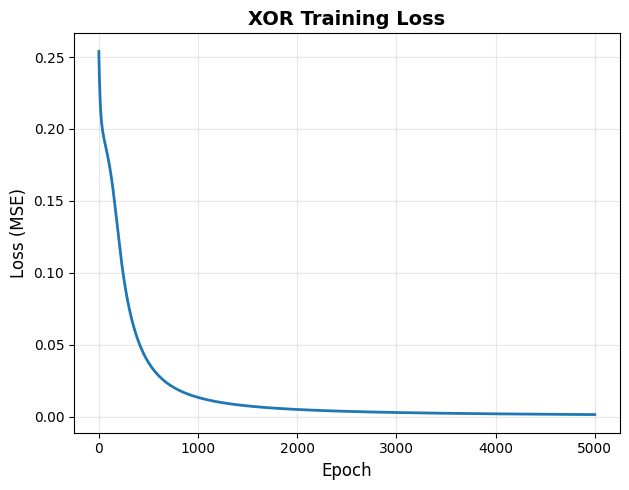

In [16]:
# Cell 7: Plot Training Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('XOR Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()



# **Section 3: The Autoencoder**

### **Load DataSet**

In [12]:
# Cell 8 : Load MNIST Dataset with More Data
print("=" * 60)
print("PHASE 2: AUTOENCODER IMPLEMENTATION")
print("=" * 60)

from tensorflow.keras.datasets import mnist

# Load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess data
X_train_flat = X_train.reshape(-1, 784).astype('float32')
X_test_flat = X_test.reshape(-1, 784).astype('float32')

# Normalize to [0, 1]
X_train_flat /= 255.0
X_test_flat /= 255.0

# Use MORE data for better learning
n_train = 30000  
n_test = 5000    

X_train_subset = X_train_flat[:n_train]
X_test_subset = X_test_flat[:n_test]

print("\n Dataset Information:")
print(f"Training samples: {X_train_subset.shape[0]}")
print(f"Test samples: {X_test_subset.shape[0]}")




PHASE 2: AUTOENCODER IMPLEMENTATION

 Dataset Information:
Training samples: 30000
Test samples: 5000


### **Autoencoder Architecture**

In [13]:
# Cell 9 : Autoencoder Architecture
print("\n" + "=" * 60)
print("BUILDING AUTOENCODER")
print("=" * 60)

from lib import Dense, ReLU, Sigmoid, MSE, SGD, Sequential

# Create autoencoder with LARGER latent space
# Architecture: 784 -> 256 -> 128 -> 64 -> 128 -> 256 -> 784
autoencoder = Sequential()

autoencoder.add(Dense(784, 256))  # Wider first layer
autoencoder.add(ReLU())

autoencoder.add(Dense(256, 128))
autoencoder.add(ReLU())

autoencoder.add(Dense(128, 64))  
autoencoder.add(ReLU())

autoencoder.add(Dense(64, 128))
autoencoder.add(ReLU())

autoencoder.add(Dense(128, 256))
autoencoder.add(ReLU())

autoencoder.add(Dense(256, 784))
autoencoder.add(Sigmoid())


# Compile with LOWER learning rate for smoother convergence
autoencoder.compile(
    loss=MSE(),
    optimizer=SGD(learning_rate=0.005)  
)

print("\n Autoencoder Architecture:")
print(f"Total layers: {len(autoencoder.layers)}")
print(" architecture (784→256→128→64→128→256→784)")




BUILDING AUTOENCODER

 Autoencoder Architecture:
Total layers: 12
 architecture (784→256→128→64→128→256→784)


### **Autoencoder Training**

In [15]:
# Cell 10: Train with More Epochs
print("\n" + "=" * 60)
print("TRAINING AUTOENCODER")
print("=" * 60)

import time

print("\n Training Configuration:")
print(f"  Epochs: 100 ")  
print(f"  Batch Size: 128")
print(f"  Learning Rate: 0.005 ")
print(f"  Training Samples: {len(X_train_subset)}")
print(f"\n  Starting training \n")

start_time = time.time()

# Train with MORE epochs
history_ae = autoencoder.fit(
    X_train_subset,
    X_train_subset,
    epochs=100,  
    batch_size=128,
    verbose=True
)

training_time = time.time() - start_time
autoencoder.save('autoencoder_Model.pkl')
print(f"\n Training completed in {training_time:.2f} seconds")
print(f"Final Loss: {history_ae['loss'][-1]:.6f}")




TRAINING AUTOENCODER

 Training Configuration:
  Epochs: 100 
  Batch Size: 128
  Learning Rate: 0.005 
  Training Samples: 30000

  Starting training 

Epoch 1/100 - Loss: 0.062016
Epoch 100/100 - Loss: 0.009616

 Training completed in 511.31 seconds
Final Loss: 0.009616


### **Autoencoder Loss Curve**


TRAINING VISUALIZATION


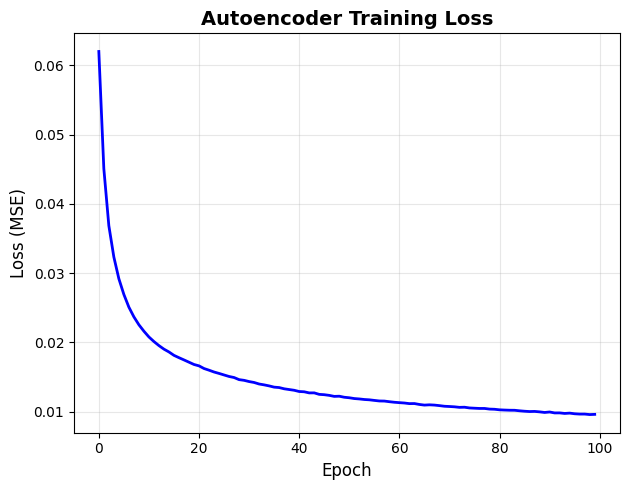


 Loss Curve Displayed

Final Reconstruction Loss

 Final Reconstruction Loss (MSE): 0.009872


In [21]:
# Cell 11: Visualize Training Progress

print("\n" + "=" * 60)
print("TRAINING VISUALIZATION")
print("=" * 60)

plt.figure(figsize=(12, 5))

# Plot 1: Full training curve
plt.subplot(1, 2, 1)
plt.plot(history_ae['loss'], linewidth=2, color='blue')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Autoencoder Training Loss', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Loss Curve Displayed")


print("\n" + "=" * 60)
print("Final Reconstruction Loss")
print("=" * 60)

autoencoder=Sequential.load("autoencoder_Model.pkl")
# Get predictions on test set
reconstructed = autoencoder.predict(X_test_subset)

# Calculate test loss
Final_Reconstruction_Loss = MSE.loss(X_test_subset, reconstructed)
print(f"\n Final Reconstruction Loss (MSE): {Final_Reconstruction_Loss:.6f}")



### **Autoencoder Reconstructed Image**

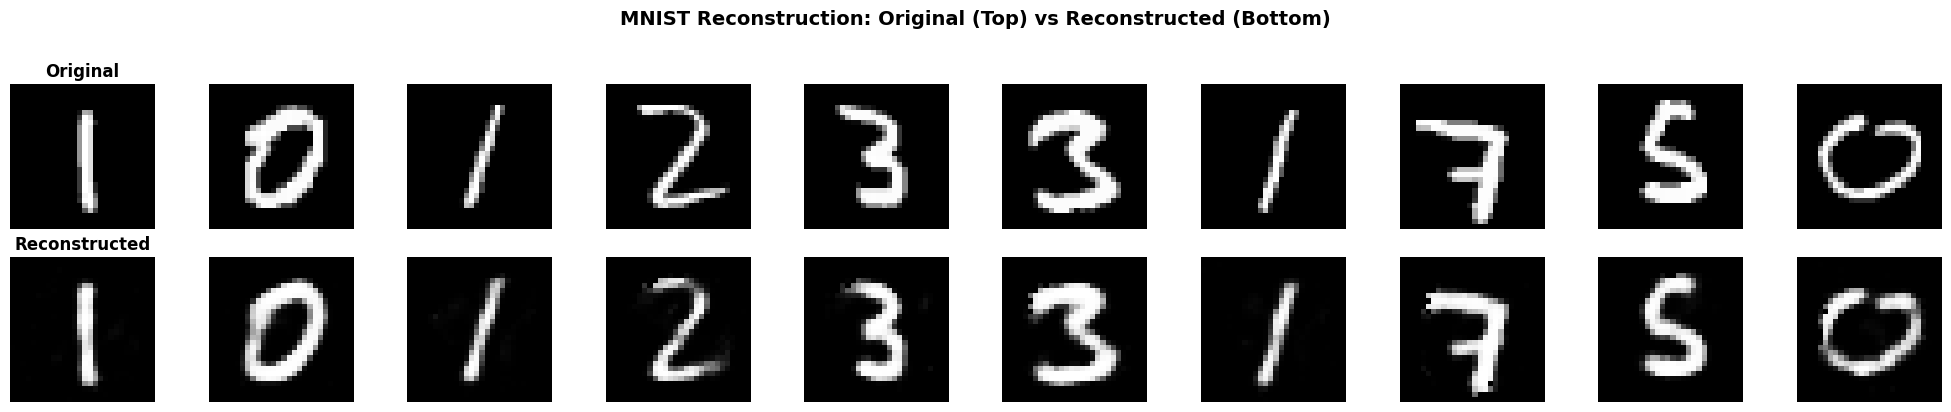


 Visualization complete
Displayed 10 random test samples


In [22]:
# Cell 12: Visualize Original vs Reconstructed Images

# Select random samples to display
n_display = 10
random_indices = np.random.choice(len(X_test_subset), n_display, replace=False)

fig, axes = plt.subplots(2, n_display, figsize=(20, 4))

for i, idx in enumerate(random_indices):
    # Original image
    original_img = X_test_subset[idx].reshape(28, 28)
    axes[0, i].imshow(original_img, cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=12, fontweight='bold')
    
    # Reconstructed image
    reconstructed_img = reconstructed[idx].reshape(28, 28)
    axes[1, i].imshow(reconstructed_img, cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=12, fontweight='bold')

plt.suptitle('MNIST Reconstruction: Original (Top) vs Reconstructed (Bottom)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n Visualization complete")
print(f"Displayed {n_display} random test samples")

# **Section 4: The Latent Space SVM Classification**

### **Feature Extraction**

In [24]:
# Cell 13: Build Encoder for Feature Extraction

print("\n" + "=" * 60)
print("Building Encoder Model")
print("=" * 60)

# Extract encoder layers (first 6 layers: 3 Dense + 3 ReLU)
encoder = Sequential()

for i in range(6):  
    layer = autoencoder.layers[i]
    encoder.add(layer)
    if hasattr(layer, 'weights'):
        print(f"  Layer {i}: Dense({layer.weights.shape[0]} -> {layer.weights.shape[1]})")
    else:
        print(f"  Layer {i}: {layer.__class__.__name__}()")

# Encoder doesn't need compilation (just forward pass)
print("\n Encoder extracted ")
print(f"Latent space dimension: 64")

print("\n" + "=" * 60)
print("EXTRACTING LATENT FEATURES")
print("=" * 60)

y_test_subset = y_test[:n_test]
X_train_latent = encoder.predict(X_train_subset)
X_test_latent = encoder.predict(X_test_subset)
y_train_subset = y_train[:n_train]

print(f"\n Feature extraction complete!")
print(f"\n  Dataset shapes:")
print(f"  X_train_latent: {X_train_latent.shape}")
print(f"  X_test_latent: {X_test_latent.shape}")
print(f"  y_train: {y_train_subset.shape}")
print(f"  y_test: {y_test_subset.shape}")




Building Encoder Model
  Layer 0: Dense(784 -> 256)
  Layer 1: ReLU()
  Layer 2: Dense(256 -> 128)
  Layer 3: ReLU()
  Layer 4: Dense(128 -> 64)
  Layer 5: ReLU()

 Encoder extracted 
Latent space dimension: 64

EXTRACTING LATENT FEATURES

 Feature extraction complete!

  Dataset shapes:
  X_train_latent: (30000, 64)
  X_test_latent: (5000, 64)
  y_train: (30000,)
  y_test: (5000,)


### **SVM training**

In [25]:
# Cell 14: Train SVM Classifier
print("\n" + "=" * 60)
print("TRAINING SVM CLASSIFIER")
print("=" * 60)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n Training SVM on latent features...")

svm_start = time.time()

# Train SVM
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_classifier.fit(X_train_latent, y_train_subset)

svm_time = time.time() - svm_start

print(f"\n SVM training completed in {svm_time:.2f} seconds")

# Make predictions
print("\n Making predictions...")
y_pred = svm_classifier.predict(X_test_latent)

# Calculate accuracy
accuracy = accuracy_score(y_test_subset, y_pred)
print(f"\n Test Accuracy: {accuracy * 100:.2f}%")


TRAINING SVM CLASSIFIER

 Training SVM on latent features...

 SVM training completed in 41.55 seconds

 Making predictions...

 Test Accuracy: 95.54%


### **Evaluation metrics and Confusion matrix**


CLASSIFICATION RESULTS

 Classification Matrices:
              precision    recall  f1-score   support

     Digit 0       0.96      0.99      0.97       460
     Digit 1       0.98      0.99      0.99       571
     Digit 2       0.95      0.95      0.95       530
     Digit 3       0.94      0.95      0.95       500
     Digit 4       0.96      0.96      0.96       500
     Digit 5       0.96      0.96      0.96       456
     Digit 6       0.97      0.96      0.96       462
     Digit 7       0.94      0.93      0.94       512
     Digit 8       0.96      0.93      0.94       489
     Digit 9       0.94      0.93      0.93       520

    accuracy                           0.96      5000
   macro avg       0.96      0.96      0.96      5000
weighted avg       0.96      0.96      0.96      5000


 Confusion Matrix:


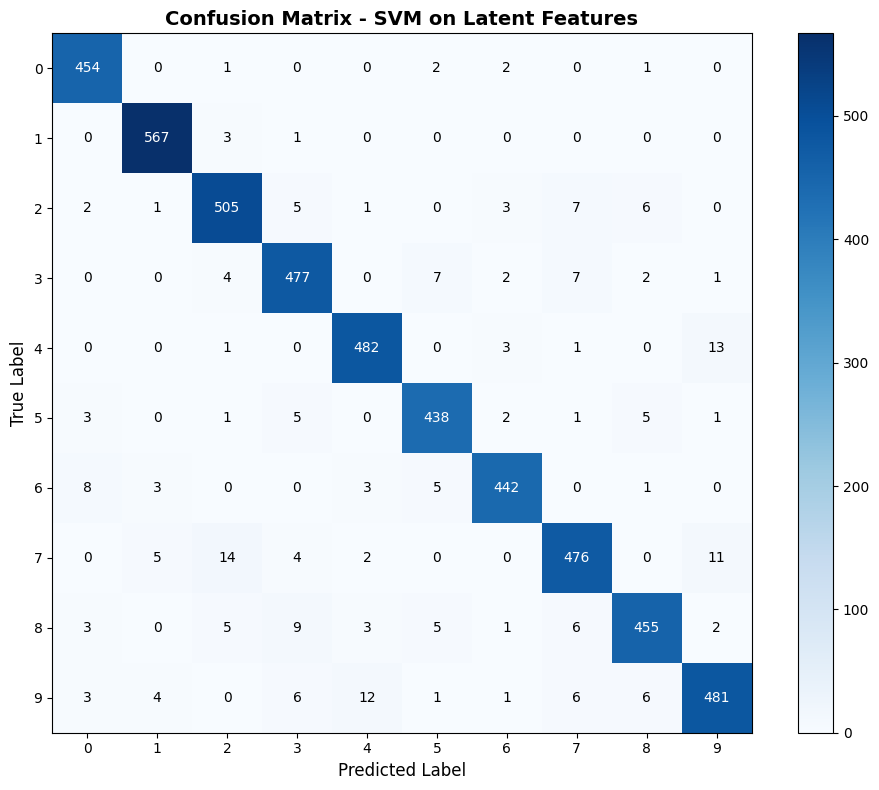


 Classification evaluation complete


In [26]:
# Cell 15: Display Classification Results
print("\n" + "=" * 60)
print("CLASSIFICATION RESULTS")
print("=" * 60)

# Classification Matrices
print("\n Classification Matrices:")
print("=" * 60)
print(classification_report(y_test_subset, y_pred, 
                          target_names=[f'Digit {i}' for i in range(10)]))

# Confusion Matrix
print("\n Confusion Matrix:")
cm = confusion_matrix(y_test_subset, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - SVM on Latent Features', 
          fontsize=14, fontweight='bold')
plt.colorbar()

tick_marks = np.arange(10)
plt.xticks(tick_marks, range(10))
plt.yticks(tick_marks, range(10))

# Add text annotations
thresh = cm.max() / 2.
for i in range(10):
    for j in range(10):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\n Classification evaluation complete")


# **Section 5: The TensorFlow/Keras implementations**

### **TensorFlow XOR Implementation**

In [30]:
# Cell 16: TensorFlow XOR Implementation 
print("=" * 60)
print(" TENSORFLOW/KERAS COMPARISON")
print("=" * 60)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as keras_layers

# Recreate XOR problem
print("XOR PROBLEM - TENSORFLOW IMPLEMENTATION")
print("=" * 60)

# Build Keras model (same architecture as our library)
tf_xor_model = keras.Sequential([
    keras_layers.Dense(4, activation='tanh', input_shape=(2,)),
    keras_layers.Dense(1, activation='sigmoid')
])

# Compile
tf_xor_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss='mse'
)


# Train
print("\n  Training TensorFlow XOR model...")
tf_xor_start = time.time()

tf_xor_history = tf_xor_model.fit(
    X_xor, y_xor,
    epochs=5000,
    batch_size=4,
    verbose=0  # Silent training
)

tf_xor_time = time.time() - tf_xor_start

# Test
tf_xor_predictions = tf_xor_model.predict(X_xor, verbose=0)
tf_xor_accuracy = np.mean((tf_xor_predictions > 0.5) == y_xor)

print(f"\n  TensorFlow XOR Results:")
print(f"  Training Time: {tf_xor_time:.2f} seconds")
print(f"  Final Loss: {tf_xor_history.history['loss'][-1]:.6f}")


print("\nPredictions:")
for i in range(4):
    print(f"  Input: {X_xor[i]} → Prediction: {tf_xor_predictions[i][0]:.4f} (Target: {y_xor[i][0]})")



 TENSORFLOW/KERAS COMPARISON
XOR PROBLEM - TENSORFLOW IMPLEMENTATION

  Training TensorFlow XOR model...

  TensorFlow XOR Results:
  Training Time: 319.83 seconds
  Final Loss: 0.001878

Predictions:
  Input: [0. 0.] → Prediction: 0.0208 (Target: 0.0)
  Input: [0. 1.] → Prediction: 0.9546 (Target: 1.0)
  Input: [1. 0.] → Prediction: 0.9529 (Target: 1.0)
  Input: [1. 1.] → Prediction: 0.0528 (Target: 0.0)


### **TensorFlow Autoencoder Implementation**

In [34]:

# Cell 17A: TensorFlow Autoencoder -  (SGD)
print("=" * 60)
print("TENSORFLOW COMPARISON #1: (SGD)")
print("=" * 60)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as keras_layers



# Build EXACT same architecture
tf_autoencoder_sgd = keras.Sequential([
    keras_layers.Dense(256, activation='relu', input_shape=(784,)),
    keras_layers.Dense(128, activation='relu'),
    keras_layers.Dense(64, activation='relu'),
    keras_layers.Dense(128, activation='relu'),
    keras_layers.Dense(256, activation='relu'),
    keras_layers.Dense(784, activation='sigmoid')
])

# EXACT same optimizer as our library
tf_autoencoder_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.005),
    loss='mse'
)

print("Architecture: 784→256→128→64→128→256→784")
print("Optimizer: SGD (lr=0.005) - IDENTICAL to our library")


# Train
print("\n Training TensorFlow with SGD...")
tf_sgd_start = time.time()

tf_sgd_history = tf_autoencoder_sgd.fit(
    X_train_subset,
    X_train_subset,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_subset, X_test_subset),
    verbose=0
)

tf_sgd_time = time.time() - tf_sgd_start

# Test
tf_sgd_reconstructed = tf_autoencoder_sgd.predict(X_test_subset, verbose=0)
tf_sgd_test_loss = np.mean(np.square(X_test_subset - tf_sgd_reconstructed))

print(f"\n TensorFlow Results (SGD):")
print(f"  Training Time: {tf_sgd_time:.2f} seconds")
print(f"  Final Training Loss: {tf_sgd_history.history['loss'][-1]:.6f}")
print(f"  Test Loss: {tf_sgd_test_loss:.6f}")


TENSORFLOW COMPARISON #1: (SGD)
Architecture: 784→256→128→64→128→256→784
Optimizer: SGD (lr=0.005) - IDENTICAL to our library

 Training TensorFlow with SGD...

 TensorFlow Results (SGD):
  Training Time: 249.59 seconds
  Final Training Loss: 0.070462
  Final Validation Loss: 0.067552
  Test Loss: 0.067552


In [35]:
# Cell 17B: TensorFlow Autoencoder - (ADAM)
print("\n" + "=" * 60)
print("TENSORFLOW COMPARISON #2:  (ADAM)")
print("=" * 60)

# Build SAME architecture
tf_autoencoder_adam = keras.Sequential([
    keras_layers.Dense(256, activation='relu', input_shape=(784,)),
    keras_layers.Dense(128, activation='relu'),
    keras_layers.Dense(64, activation='relu'),
    keras_layers.Dense(128, activation='relu'),
    keras_layers.Dense(256, activation='relu'),
    keras_layers.Dense(784, activation='sigmoid')
])

# Use Adam optimizer
tf_autoencoder_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.005),
    loss='mse'
)

print("Architecture: 784→256→128→64→128→256→784 (SAME)")
print("Optimizer: Adam (lr=0.005)")


# Train
print("\n Training TensorFlow with Adam...")
tf_adam_start = time.time()

tf_adam_history = tf_autoencoder_adam.fit(
    X_train_subset,
    X_train_subset,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_subset, X_test_subset),
    verbose=0
)

tf_adam_time = time.time() - tf_adam_start

# Test
tf_adam_reconstructed = tf_autoencoder_adam.predict(X_test_subset, verbose=0)
tf_adam_test_loss = np.mean(np.square(X_test_subset - tf_adam_reconstructed))

print(f"\n TensorFlow Results (Adam):")
print(f"  Training Time: {tf_adam_time:.2f} seconds")
print(f"  Final Training Loss: {tf_adam_history.history['loss'][-1]:.6f}")
print(f"  Test Loss: {tf_adam_test_loss:.6f}")

# Compare both TensorFlow versions
print("\n" + "=" * 60)
print("TENSORFLOW SGD vs ADAM COMPARISON")
print("=" * 60)
print(f"\n  Our Library (SGD):        Loss = {history_ae['loss'][-1]:.6f}")
print(f"  TensorFlow (SGD):         Loss = {tf_sgd_test_loss:.6f}")
print(f"  TensorFlow (Adam):        Loss = {tf_adam_test_loss:.6f}")



TENSORFLOW COMPARISON #2:  (ADAM)
Architecture: 784→256→128→64→128→256→784 (SAME)
Optimizer: Adam (lr=0.005)

 Training TensorFlow with Adam...

 TensorFlow Results (Adam):
  Training Time: 301.42 seconds
  Final Training Loss: 0.004999
  Final Validation Loss: 0.005983
  Test Loss: 0.005983

TENSORFLOW SGD vs ADAM COMPARISON

  Our Library (SGD):        Loss = 0.009616
  TensorFlow (SGD):         Loss = 0.067552
  TensorFlow (Adam):        Loss = 0.005983


### **Training Comparison**


THREE-WAY TRAINING COMPARISON


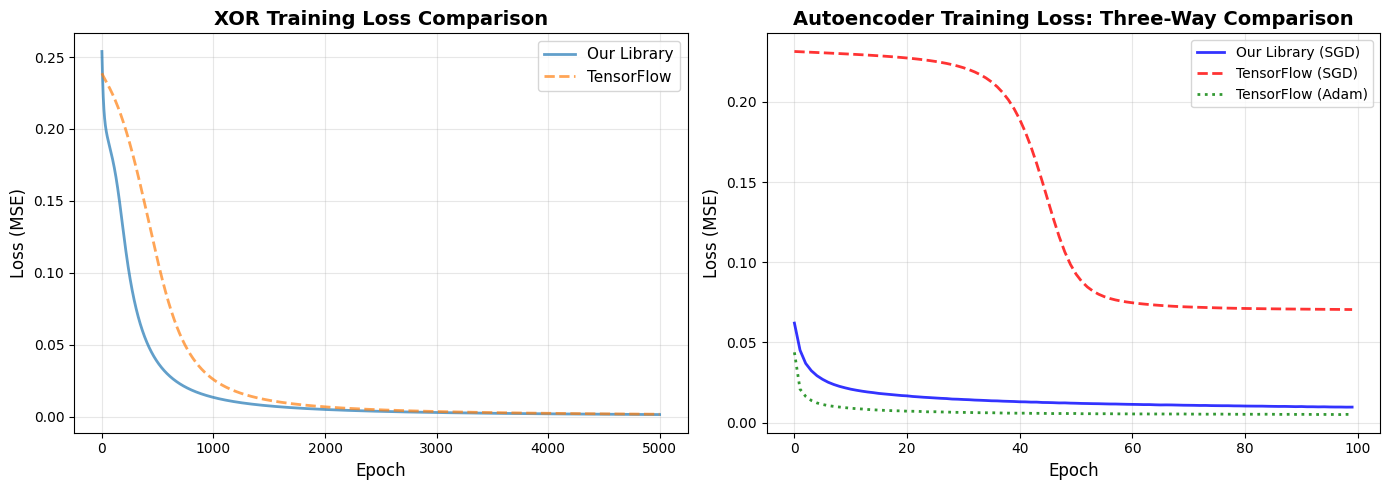


  Training curves comparison displayed


In [42]:
# Cell 18: Three-Way Training Curve Comparison
print("\n" + "=" * 60)
print("THREE-WAY TRAINING COMPARISON")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XOR Comparison (unchanged)
axes[0].plot(history['loss'], label='Our Library', linewidth=2, alpha=0.7)
axes[0].plot(tf_xor_history.history['loss'], label='TensorFlow', 
             linewidth=2, alpha=0.7, linestyle='--')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('XOR Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Autoencoder THREE-WAY Comparison
axes[1].plot(history_ae['loss'], label='Our Library (SGD)', 
             linewidth=2, alpha=0.8, color='blue')
axes[1].plot(tf_sgd_history.history['loss'], label='TensorFlow (SGD)', 
             linewidth=2, alpha=0.8, linestyle='--', color='red')
axes[1].plot(tf_adam_history.history['loss'], label='TensorFlow (Adam)', 
             linewidth=2, alpha=0.8, linestyle=':', color='green')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss (MSE)', fontsize=12)
axes[1].set_title('Autoencoder Training Loss: Three-Way Comparison', 
                  fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n  Training curves comparison displayed")



### **Reconstruction Comparison**


RECONSTRUCTION QUALITY: FOUR-WAY COMPARISON


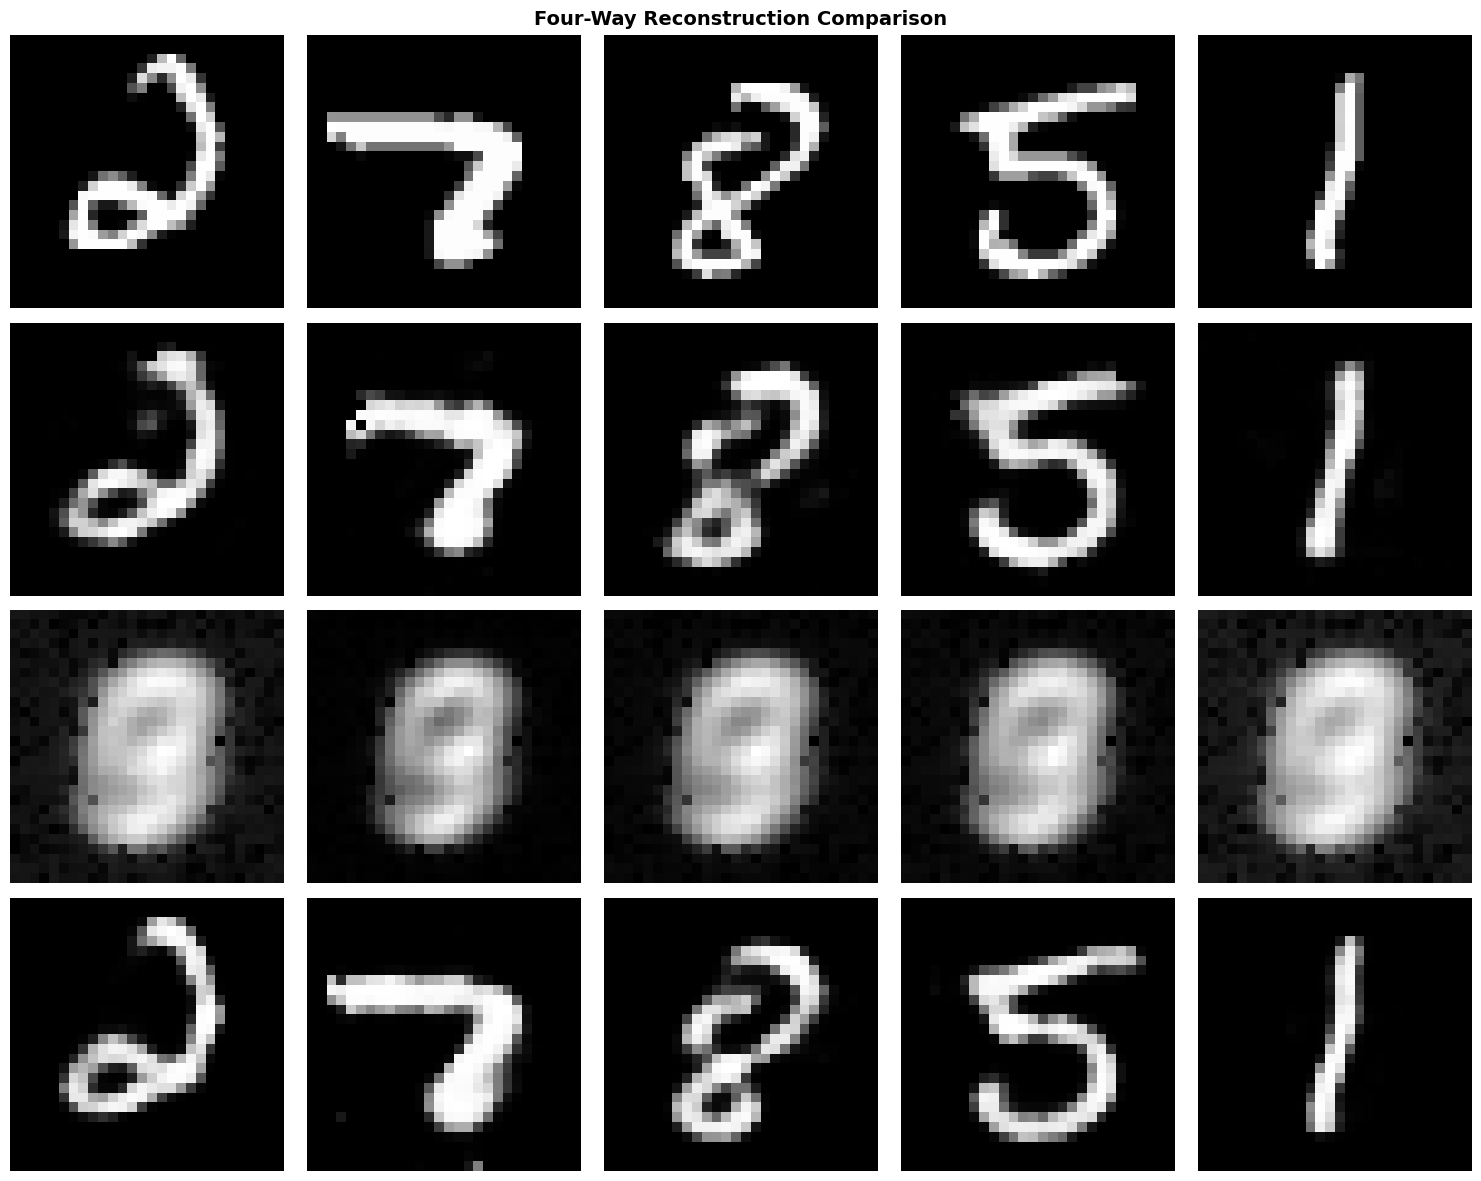


✓ Visual comparison complete

Quality Assessment:
  Row 1 (Original) 
  Row 2 (Our Library using SGD)
  Row 3 (TensorFlow SGD)
  Row 4 (TensorFlow Adam)


In [44]:
# Cell 19: Four-Row Visual Comparison
print("\n" + "=" * 60)
print("RECONSTRUCTION QUALITY: FOUR-WAY COMPARISON")
print("=" * 60)

# Select 5 random samples
n_compare = 5
compare_indices = np.random.choice(len(X_test_subset), n_compare, replace=False)

fig, axes = plt.subplots(4, n_compare, figsize=(15, 12))

for i, idx in enumerate(compare_indices):
    # Row 1: Original
    original_img = X_test_subset[idx].reshape(28, 28)
    axes[0, i].imshow(original_img, cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=12, fontweight='bold')
    
    # Row 2: Our library
    our_recon = reconstructed[idx].reshape(28, 28)
    axes[1, i].imshow(our_recon, cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Our Library\n(SGD)', fontsize=12, fontweight='bold')
    
    # Row 3: TensorFlow SGD
    tf_sgd_recon = tf_sgd_reconstructed[idx].reshape(28, 28)
    axes[2, i].imshow(tf_sgd_recon, cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('TensorFlow\n(SGD)', fontsize=12, fontweight='bold')
    
    # Row 4: TensorFlow Adam
    tf_adam_recon = tf_adam_reconstructed[idx].reshape(28, 28)
    axes[3, i].imshow(tf_adam_recon, cmap='gray')
    axes[3, i].axis('off')
    if i == 0:
        axes[3, i].set_ylabel('TensorFlow\n(Adam)', fontsize=12, fontweight='bold')

plt.suptitle('Four-Way Reconstruction Comparison', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n✓ Visual comparison complete")
print("\nQuality Assessment:")
print("  Row 1 (Original) ")
print(f"  Row 2 (Our Library using SGD)")
print(f"  Row 3 (TensorFlow SGD)")
print(f"  Row 4 (TensorFlow Adam)")



### **Training Time Comparison**

In [ ]:
# Cell 20: Training Time :
print("\n" + "=" * 60)
print("Training Time Analysis")
print("=" * 60)

print(f"   • Our Library: {training_time:.2f}s")
print(f"   • TensorFlow SGD: {tf_sgd_time:.2f}s")
print(f"   • TensorFlow Adam: {tf_adam_time:.2f}s")



Training Time Analysis
   • Our Library: 511.31s
   • TensorFlow SGD: 249.59s
   • TensorFlow Adam: 301.42s
